Part 1 Section on; Step 3. Replication

In [1]:
#import necessary libraries.
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error

In [2]:
# Import the data for analysis.
fund_data = pd.read_csv('Issues of Treasury Bonds (1).csv')
fund_data

,Issue Date,Issue No,ISIN Number,Tenor,Face Value (Kshs Millions),Maturity Date,Coupon Rate,Redemption Yield
0,09/12/2024,FXD1/2018/020,KE5000008325,10,20741.700,01/03/2038,13.200,15.1121
1,09/12/2024,FXD1/2023/010,KE8000005432,10,35833.400,31/01/2033,14.151,14.6913
2,14/10/2024,FXD1/2022/010,KE7000009436,10,3785.000,03/05/2032,13.490,16.9516
3,14/10/2024,FXD1/2016/010,KE5000006329,10,28884.950,17/08/2026,15.039,16.9837
4,23/09/2024,FXD1/2016/020,KE5000006543,20,9.224,01/09/2036,14.000,17.2854
...,...,...,...,...,...,...,...,...
312,26/03/2007,FXD1/2007/15,KE1000001345,15,3654.600,07/03/2022,14.500,14.8960
313,NaN,000001-916,KE5000008549,25,22991.850,25/05/2020,13.400,13.5990
314,NaN,000001-361,KE6000007218,15,5191.250,05/02/2035,12.756,12.7560
315,NaN,FXD1/2012/020,KE4000003949,20,4054.300,01/11/2032,12.000,12.5870


In [3]:
# Dropping null values.
fund_data.dropna(inplace=True)
fund_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 313 entries, 0 to 312
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Issue Date                  313 non-null    object 
 1   Issue No                    313 non-null    object 
 2   ISIN Number                 313 non-null    object 
 3   Tenor                       313 non-null    int64  
 4   Face Value (Kshs Millions)  313 non-null    float64
 5   Maturity Date               313 non-null    object 
 6   Coupon Rate                 313 non-null    float64
 7   Redemption Yield            313 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 22.0+ KB


In [4]:
fund_data.describe

<bound method NDFrame.describe of      Issue Date       Issue No   ISIN Number  Tenor  \
0    09/12/2024  FXD1/2018/020  KE5000008325     10   
1    09/12/2024  FXD1/2023/010  KE8000005432     10   
2    14/10/2024  FXD1/2022/010  KE7000009436     10   
3    14/10/2024  FXD1/2016/010  KE5000006329     10   
4    23/09/2024  FXD1/2016/020  KE5000006543     20   
..          ...            ...           ...    ...   
308  31/03/2008   FXD1/2008/15  KE1000001428     15   
309  26/11/2007   FXD3/2007/15  KE1000001360     15   
310  25/06/2007   FXD2/2007/15  KE1000001352     15   
311  01/06/2007  SFX1/2007/015            KE     15   
312  26/03/2007   FXD1/2007/15  KE1000001345     15   

     Face Value (Kshs Millions) Maturity Date  Coupon Rate  Redemption Yield  
0                     20741.700    01/03/2038       13.200           15.1121  
1                     35833.400    31/01/2033       14.151           14.6913  
2                      3785.000    03/05/2032       13.490          

In [5]:
#Dispersion ratios.
summary_stats =fund_data[["Tenor","Face Value (Kshs Millions)","Coupon Rate","Redemption Yield"]].describe()
summary_stats

,Tenor,Face Value (Kshs Millions),Coupon Rate,Redemption Yield
count,313.000000,313.000000,313.000000,313.000000
mean,11.952077,17067.958310,12.967276,13.590660
std,6.190947,21209.841999,1.959226,2.004255
min,0.000000,9.224000,8.790000,8.633000
25%,7.000000,6305.380000,12.000000,12.456000
50%,10.000000,10923.550000,12.705000,13.215000
75%,15.000000,20734.730000,13.924000,14.257000
max,30.000000,240334.850000,18.460700,18.769700


In [6]:
#Load the data set.
x = ["Tenor","Face Value (Kshs Millions)","Coupon Rate"]
X =fund_data[x]
y = fund_data["Redemption Yield"]  # Target variable
X
y

0      15.1121
1      14.6913
2      16.9516
3      16.9837
4      17.2854
        ...   
308    13.3100
309    13.3130
310    12.9680
311    14.5000
312    14.8960
Name: Redemption Yield, Length: 313, dtype: float64

In [7]:
#Initialize K-Fold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)  

In [8]:
#Perform Cross-Validation ;formulate model.
model = RandomForestClassifier()
model

RandomForestClassifier()

In [9]:
# accuracy
accuracy_scores = []
accuracy_scores

[]

In [10]:
cutoff_test=int(len(y)*0.95)
y_train = y.iloc[:cutoff_test]
y_test = y.iloc[cutoff_test:]

In [11]:
from statsmodels.tsa.ar_model import AutoReg

In [12]:
model = AutoReg(y_train,lags=25).fit()

In [13]:
model.predict()
model.predict().isnull().sum()       


25

In [14]:
#Training Mean Absolute Value
y_pred=model.predict().dropna()
training_mae=mean_absolute_error(y_train.iloc[25:],y_pred).round(2)
print("Training MAE:", training_mae)

Training MAE: 0.65


In [15]:
#y train residuals
y_train_resid =model.resid
y_train_resid.tail()


292   -1.029022
293   -0.896215
294   -2.810528
295   -1.037303
296   -2.160570
dtype: float64

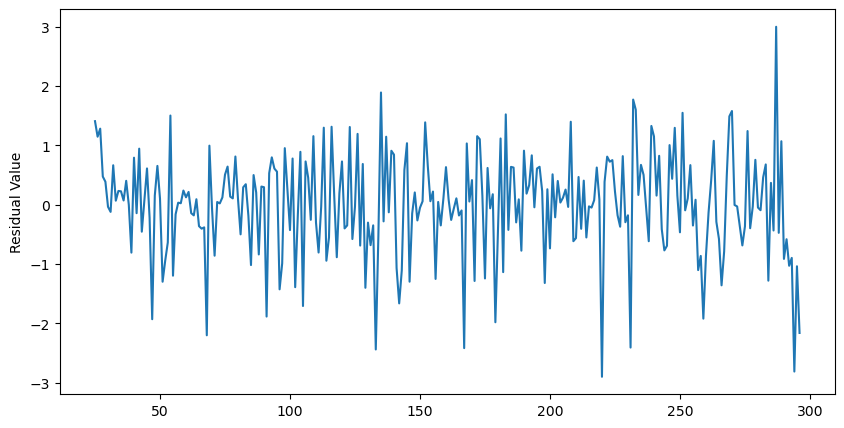

In [16]:
# plot of y_train_resid.
import plotly.express as px
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
y_train_resid.plot(ylabel="Residual Value",ax=ax);

Text(0.5, 1.0, 'AR(25),Distribution of Residuals')

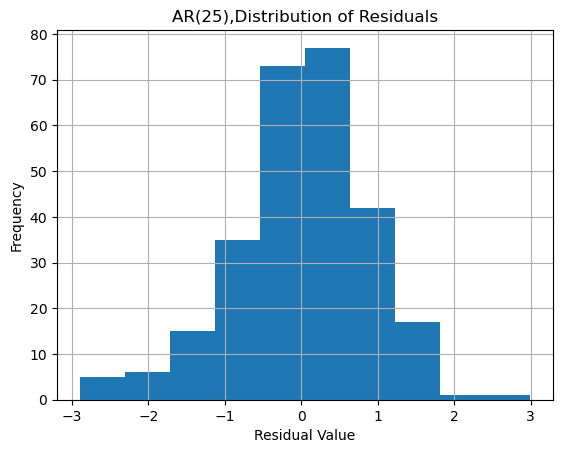

In [17]:
# Create a histogram of y_train_resid.
y_train_resid.hist()
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("AR(25),Distribution of Residuals")


In [18]:
#Computing the test mean absolute error for your model.
y_pred_test = model.predict(y_test.index.min(),y_test.index.max())
test_mae = mean_absolute_error(y_test,y_pred_test)
print("Test MAE:", test_mae)


Test MAE: 2.4707125787604425


In [19]:
#Checking the accuracy score
y_train.value_counts()
y_train.value_counts(normalize=True)
y_train.value_counts(normalize=True).max()

acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))


Baseline Accuracy: 0.02
